# PyTorch로 시작하는 기본 MLP 회귀 모델 학습

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

torch.manual_seed(0)

## 2. 입력 데이터와 타겍 데이터 설정

In [2]:
input_tensor = torch.tensor([[3, 0.31, 22.6, 11.7],
                             [1, 2.48, 13.5, 7.52],
                             [3, 1.52, 18.9, 17.1]], dtype=torch.float32)

target = torch.tensor([[307], [110], [369]], dtype=torch.float32)

In [5]:
from torch.utils.data import TensorDataset, DataLoader

dataset = TensorDataset(input_tensor, target) 
#텐서를 감싸는 데이터 셋으로 첫번째 인자로는 특성을 나타내는 입력데이터 텐서
# 두번째 인자로는 레이블을 나타내는 타겟 데이터 텐서
data_loader = DataLoader(dataset, batch_size=1, shuffle=True)
# data loader 생성 
# DataLoader 클래스는 데이터셋을 배치 단위로 나누고, 학습 시 데이터를 섞어서 제공하는 기능을 제공합니다.
# batch_size=1은 한 번에 하나의 샘플씩 학습에 사용하겠다는 의미이고, 
# shuffle=True는 학습 시 데이터셋을 무작위로 섞어서 제공하겠다는 의미입니다.

In [6]:
class SimpleMLP(nn.Module):
    def __init__(self, input_size):
        super(SimpleMLP, self).__init__()
        self.hidden = nn.Linear(input_size, 5) # 은닉층을 정의, input_size=입력층 크기, 5는 은닉층의 뉴런수
        self.relu = nn.ReLU() #활성화 함수를 정의 
        self.output = nn.Linear(5, 1) #은닉층 뉴런 수 = 5, 출력층 뉴런수 1
    
    def forward(self, x):
        x = self.hidden(x)
        x = self.relu(x)
        x = self.output(x)
        return x

In [17]:
#하이퍼파라미터 설정 
learning_rate = 0.001
epochs = 100

In [9]:
#신경망 모델 인스턴스 생성
model = SimpleMLP(input_size=input_tensor.shape[1])

In [11]:
#손실 함수와 최적화 알고리즘 설정 
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=learning_rate)

In [20]:
# 학습 
loss_history = []

# 학습 루프
for epoch in range(epochs):
    for inputs, targets in data_loader:

        outputs = model(inputs)
        loss = criterion(outputs, targets)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        loss_history.append(loss.item())
    
    if (epoch+1) % 100 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

Epoch [100/100], Loss: 2033.7271


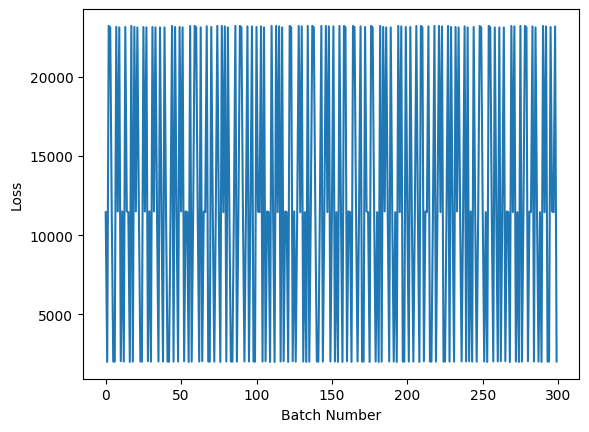

In [21]:
plt.plot(loss_history)
plt.xlabel('Batch Number')
plt.ylabel('Loss')
plt.show()